# word 2 vec
- 추론 기반 - 맥락이 주어졌을때, 특정 위치의 단어 추론

In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import cupy as np 
import matplotlib.pyplot as plt

GPU = True

## 고정길이 벡터 변환
- 원 핫 인코딩
- 아이디에 대해 해당 인덱스만 1이고 나머지는 0인 스파스 벡터로 표현

## CBOW
- 맥락을 입력으로 타깃을 추측
    - $$P(w_t|w_{t-1}, w_{t+1}) $$
    - 손실함수는 주어진 맥락에서 관측된 중심 단어에 대한 음의 로그 가능도 $$L =- \log P(w_t|w_{t-1}, w_{t+1})$$
    - 전체 데이터에 대한 손실 $$L_T = -\frac{1}{T}\sum_{t=1}{T}\log P(w_t|w_{t-1}, w_{t+1})$$
- 원핫 입력
- n개 입력 벡터 첫 레이어 변환 이후 평균 집계
- 학습한 모델의 입력 가중치를 단어의 벡터로 간주

In [12]:
from b2.common.layers import MatMul, SoftmaxWithLoss


class SimpleCBOW:
    def __init__(self, vocab_size, hidden_size):
        V, H = vocab_size, hidden_size

        W_in = 0.01 * np.random.randn(V, H).astype('f')
        W_out = 0.01 * np.random.randn(H, V).astype('f')
        

        self.in_layer0 = MatMul(W_in)
        self.in_layer1 = MatMul(W_in)
        self.out_layer = MatMul(W_out)
        self.loss_layer = SoftmaxWithLoss()

        layers = [self.in_layer0, self.in_layer1, self.out_layer]
        self.params, self.grads = [], []
        for layer in layers:
            self.params += layer.params
            self.grads += layer.grads

        self.word_vecs = W_in

    def forward(self, contexts, target):
        h0 = self.in_layer0.forward(contexts[:, 0])
        h1 = self.in_layer1.forward(contexts[:, 1])
        h = (h0 + h1) * 0.5
        score = self.out_layer.forward(h)
        loss = self.loss_layer.forward(score, target)
        return loss

    def backward(self, dout=1):
        ds = self.loss_layer.backward(dout)
        da = self.out_layer.backward(ds)
        da *= 0.5
        self.in_layer1.backward(da)
        self.in_layer0.backward(da)
        return None


------------------------------------------------------------
                       GPU Mode (cupy)
------------------------------------------------------------



In [13]:
def create_contexts_target(corpus, window_size=1):
    target = corpus[window_size:-window_size]
    contexts = []

    for idx in range(window_size, len(corpus) - window_size):
        cs = []
        for t in range(-window_size, window_size + 1):
            if t == 0:
                continue
            cs.append(corpus[idx + t])
        contexts.append(cs)

    return np.array(contexts), np.array(target)


In [14]:
def convert_one_hot(corpus, vocab_size):
    N = corpus.shape[0]

    one_hot = None
    if corpus.ndim == 1:
        one_hot = np.zeros((N, vocab_size), dtype=np.int32)
        for idx, word_id in enumerate(corpus):
            one_hot[idx, word_id] = 1

    elif corpus.ndim == 2:
        C = corpus.shape[1]
        one_hot = np.zeros((N, C, vocab_size), dtype=np.int32)
        for idx_0, word_ids in enumerate(corpus):
            for idx_1, word_id in enumerate(word_ids):
                one_hot[idx_0, idx_1, word_id] = 1

    return one_hot

In [15]:
from b2.common.util import preprocess

text = "you say hello and i say hello ."
corpus, word2id, id2word = preprocess(text)
context, target = create_contexts_target(corpus)

vocab_size = len(word2id)
context = convert_one_hot(context, vocab_size)
target = convert_one_hot(context, vocab_size)

| 에폭 1 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 2 |  반복 1 / 2 | 시간 1[s] | 손실 1.95
| 에폭 3 |  반복 1 / 2 | 시간 1[s] | 손실 1.95
| 에폭 4 |  반복 1 / 2 | 시간 1[s] | 손실 1.95
| 에폭 5 |  반복 1 / 2 | 시간 1[s] | 손실 1.95
| 에폭 6 |  반복 1 / 2 | 시간 1[s] | 손실 1.95
| 에폭 7 |  반복 1 / 2 | 시간 1[s] | 손실 1.95
| 에폭 8 |  반복 1 / 2 | 시간 1[s] | 손실 1.95
| 에폭 9 |  반복 1 / 2 | 시간 1[s] | 손실 1.95
| 에폭 10 |  반복 1 / 2 | 시간 1[s] | 손실 1.95
| 에폭 11 |  반복 1 / 2 | 시간 1[s] | 손실 1.94
| 에폭 12 |  반복 1 / 2 | 시간 1[s] | 손실 1.94
| 에폭 13 |  반복 1 / 2 | 시간 1[s] | 손실 1.94
| 에폭 14 |  반복 1 / 2 | 시간 1[s] | 손실 1.94
| 에폭 15 |  반복 1 / 2 | 시간 1[s] | 손실 1.94
| 에폭 16 |  반복 1 / 2 | 시간 1[s] | 손실 1.94
| 에폭 17 |  반복 1 / 2 | 시간 1[s] | 손실 1.94
| 에폭 18 |  반복 1 / 2 | 시간 1[s] | 손실 1.94
| 에폭 19 |  반복 1 / 2 | 시간 1[s] | 손실 1.94
| 에폭 20 |  반복 1 / 2 | 시간 1[s] | 손실 1.94
| 에폭 21 |  반복 1 / 2 | 시간 1[s] | 손실 1.94
| 에폭 22 |  반복 1 / 2 | 시간 1[s] | 손실 1.94
| 에폭 23 |  반복 1 / 2 | 시간 1[s] | 손실 1.94
| 에폭 24 |  반복 1 / 2 | 시간 1[s] | 손실 1.94
| 에폭 25 |  반복 1 / 2 | 시간 1[s] | 손실 1.94
| 에폭 26 |

/home/esillileu/abstract-dissection/deep-learning/03_numpy/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/esillileu/abstract-dissection/deep-learning/03_numpy/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48373 (\N{HANGUL SYLLABLE BOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/esillileu/abstract-dissection/deep-learning/03_numpy/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/esillileu/abstract-dissection/deep-learning/03_numpy/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byte

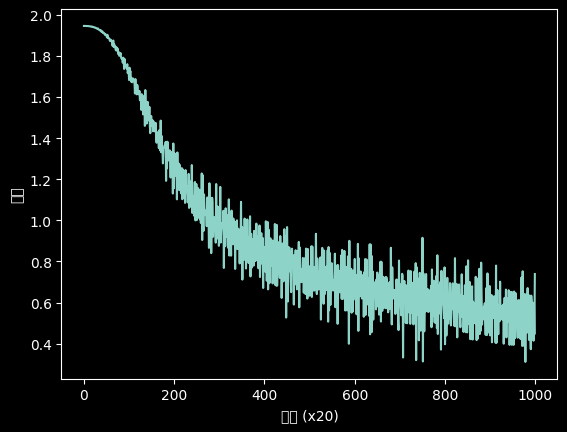

you [-1.0360892  -1.1645415  -1.5636094  -0.92269516  0.9682372 ]
say [ 1.1426872   0.22717918 -1.3167778   1.1438675  -1.1377861 ]
goodbye [-0.94162995 -0.6089703  -0.26095563 -1.0420785   1.0151433 ]
and [ 0.8689641  1.8569816 -1.3699741  0.7128666 -0.7344511]
i [-0.9080118  -0.5905364  -0.27263907 -1.0122224   0.995441  ]
hello [-1.0283878  -1.1436615  -1.5557451  -0.94348097  0.9866387 ]
. [ 1.1236019 -1.7074542 -0.6404771  1.158675  -1.1917222]


In [16]:
from b2.common.trainer import Trainer
from b2.common.optimizer import Adam

window_size = 1
hidden_size = 5
batch_size = 3
max_epoch = 1000

text = 'You say goodbye and I say hello.'
corpus, word_to_id, id_to_word = preprocess(text)

vocab_size = len(word_to_id)
contexts, target = create_contexts_target(corpus, window_size)
target = convert_one_hot(target, vocab_size)
contexts = convert_one_hot(contexts, vocab_size)

model = SimpleCBOW(vocab_size, hidden_size)
optimizer = Adam()
trainer = Trainer(model, optimizer)

trainer.fit(contexts, target, max_epoch, batch_size)
trainer.plot()

word_vecs = model.word_vecs
for word_id, word in id_to_word.items():
    print(word, word_vecs[word_id])



## skip gram 

In [17]:
from b2.common.layers import MatMul, SoftmaxWithLoss


class SimpleSkipGram:
    def __init__(self, vocab_size, hidden_size):
        V, H = vocab_size, hidden_size

        W_in = 0.01 * np.random.randn(V, H).astype('f')
        W_out = 0.01 * np.random.randn(H, V).astype('f')

        self.in_layer = MatMul(W_in)
        self.out_layer = MatMul(W_out)
        self.loss_layer1 = SoftmaxWithLoss()
        self.loss_layer2 = SoftmaxWithLoss()

        layers = [self.in_layer, self.out_layer]
        self.params, self.grads = [], []
        for layer in layers:
            self.params += layer.params
            self.grads += layer.grads

        self.word_vecs = W_in

    def forward(self, contexts, target):
        h = self.in_layer.forward(target)
        s = self.out_layer.forward(h)
        l1 = self.loss_layer1.forward(s, contexts[:, 0])
        l2 = self.loss_layer2.forward(s, contexts[:, 1])
        loss = l1 + l2
        return loss

    def backward(self, dout=1):
        dl1 = self.loss_layer1.backward(dout)
        dl2 = self.loss_layer2.backward(dout)
        ds = dl1 + dl2
        dh = self.out_layer.backward(ds)
        self.in_layer.backward(dh)
        return None


| 에폭 1 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 2 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 3 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 4 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 5 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 6 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 7 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 8 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 9 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 10 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 11 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 12 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 13 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 14 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 15 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 16 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 17 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 18 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 19 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 20 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 21 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 22 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 23 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 24 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 25 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 26 |

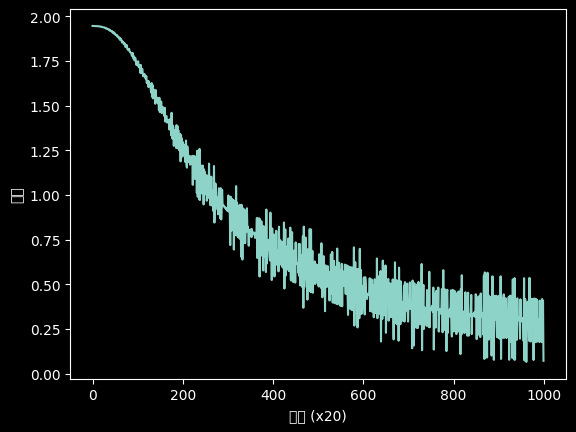

In [18]:

window_size = 1
hidden_size = 5
batch_size = 3
max_epoch = 1000

text = 'You say goodbye and I say hello.'
corpus, word_to_id, id_to_word = preprocess(text)

vocab_size = len(word_to_id)
contexts, target = create_contexts_target(corpus, window_size)
target = convert_one_hot(target, vocab_size)
contexts = convert_one_hot(contexts, vocab_size)

model = SimpleCBOW(vocab_size, hidden_size)
optimizer = Adam()
trainer = Trainer(model, optimizer)

trainer.fit(contexts, target, max_epoch, batch_size)
trainer.plot()

In [19]:
word_vecs = model.word_vecs
for word_id, word in id_to_word.items():
    print(word, word_vecs[word_id])

you [ 1.4681982 -0.9691192  0.9219097 -0.9259428 -1.4019448]
say [ 1.1813307  1.1537824 -1.1825148  1.1877661 -0.3135945]
goodbye [-0.54962504 -1.1298772   1.1062444  -1.1401986   0.4097573 ]
and [ 0.5450018  0.9718343 -0.9639992  0.9594475 -1.7705511]
i [-0.5459428 -1.140113   1.1131396 -1.1161816  0.4318766]
hello [ 1.470728  -0.9672803  0.9176803 -0.9181887 -1.4023638]
. [ 1.3427367  1.0529934 -1.1138784  1.1123962  1.6446416]


## embeding
- 임베딩 행렬에서 행을 꺼내는 연산
- 원 핫 인코딩 입력과 가중치의 행렬곱과 동치
- 조회한 행에만 그레디언트가 흐름
- $$\frac{\partial L}{\partial W} = x^T\frac{\partial L}{\partial h}$$


In [20]:
class Embedding:
    def __init__(self, W):
        self.params = [W]
        self.grads = [np.zeros_like(W)]
        self.idx = None

    def forward(self, idx):
        (W,) = self.params
        self.idx = idx
        out = W[idx]
        return out

    def backward(self, dout):
        (dW,) = self.grads
        dW[...] = 0
        if GPU:
            import cupyx
            cupyx.scatter_add(dW, self.idx, dout)
        else:
            np.add.at(dW, self.idx, dout)

        return None


### embeding dot
- 임베딩을 뽑아서 입력과 내적
- 

In [21]:
class EmbeddingDot:
    def __init__(self, W):
        self.embed = Embedding(W)
        self.params = self.embed.params
        self.grads = self.embed.grads
        self.cache = None

    def forward(self, h, idx):
        target_W = self.embed.forward(idx) 
        out = np.sum(target_W * h, axis=1) # 배치 내적

        self.cache = (h, target_W)
        return out

    def backward(self, dout):
        h, target_W = self.cache
        dout = dout.reshape(dout.shape[0], 1)
        dtarget_W = dout * h
        self.embed.backward(dtarget_W)
        dh = dout * target_W
        return dh

## 네거티브 샘플링
- 다중 분류 문제를 복수의 이진 분류 문제로 근사
- 정답에 대해 이진 분류
- 오답을 일부 샘플링하여 이진분류 - 시그모이드
- 각 로스의 전체 합산
    - $$L = -\log \sigma (h\cdot u_t) - \sum_{i=1}^K\log \sigma( -h\cdot u_{n_i} )$$

### 샘플링
- 말뭉치의 확률 분포에 따라 샘플링 수행
- 거듭제곱 평활화로 유니그램 분포 평탄화 - 0.75승
    - $$P'(w_i) = \frac{P(w_i)^{0.75}}{\sum_j^n P(w_j)^{0.75}}$$

In [22]:
import collections

GPU = True
class UnigramSampler:
    def __init__(self, corpus, power, sample_size):
        self.sample_size = sample_size
        self.vocab_size = None
        self.word_p = None

        counts = collections.Counter()
        for word_id in corpus:
            counts[word_id] += 1

        vocab_size = len(counts)
        self.vocab_size = vocab_size

        self.word_p = np.zeros(vocab_size)
        for i in range(vocab_size):
            self.word_p[i] = counts[i]

        self.word_p = np.power(self.word_p, power)
        self.word_p /= np.sum(self.word_p)

    def get_negative_sample(self, target):
        batch_size = target.shape[0]

        if not GPU:
            negative_sample = np.zeros((batch_size, self.sample_size), dtype=np.int32)

            for i in range(batch_size):
                p = self.word_p.copy()
                target_idx = target[i]
                p[target_idx] = 0
                p /= p.sum()
                negative_sample[i, :] = np.random.choice(self.vocab_size, size=self.sample_size, replace=False, p=p)
        else:
            negative_sample = np.random.choice(self.vocab_size, size=(batch_size, self.sample_size),
                                               replace=True, p=self.word_p)

        return negative_sample


In [23]:
from b2.common.layers import SigmoidWithLoss

class NegativeSamplingLoss:
    def __init__(self, W, corpus, power=0.75, sample_size=5):
        self.sample_size = sample_size
        self.sampler = UnigramSampler(corpus, power, sample_size)
        self.loss_layers = [SigmoidWithLoss() for _ in range(sample_size + 1)]
        self.embed_dot_layers = [EmbeddingDot(W) for _ in range(sample_size + 1)]

        self.params, self.grads = [], []
        for layer in self.embed_dot_layers:
            self.params += layer.params
            self.grads += layer.grads

    def forward(self, h, target):
        batch_size = target.shape[0]
        negative_sample = self.sampler.get_negative_sample(target)

        score = self.embed_dot_layers[0].forward(h, target)
        correct_label = np.ones(batch_size, dtype=np.int32)
        loss = self.loss_layers[0].forward(score, correct_label)

        negative_label = np.zeros(batch_size, dtype=np.int32)
        for i in range(self.sample_size):
            negative_target = negative_sample[:, i]
            score = self.embed_dot_layers[1 + i].forward(h, negative_target)
            loss += self.loss_layers[1 + i].forward(score, negative_label)

        return loss

    def backward(self, dout=1):
        dh = 0
        for l0, l1 in zip(self.loss_layers, self.embed_dot_layers):
            dscore = l0.backward(dout)
            dh += l1.backward(dscore)

        return dh


In [24]:
class CBOW:
    def __init__(self, vocab_size, hidden_size, window_size, corpus):
        V, H = vocab_size, hidden_size

        W_in = 0.01 * np.random.randn(V, H).astype('f')
        W_out = 0.01 * np.random.randn(V, H).astype('f')

        self.in_layers = []
        for i in range(2 * window_size):
            layer = Embedding(W_in)
            self.in_layers.append(layer)
        self.ns_loss = NegativeSamplingLoss(W_out, corpus, power=0.75, sample_size=5)

        layers = self.in_layers + [self.ns_loss]
        self.params, self.grads = [], []
        for layer in layers:
            self.params += layer.params
            self.grads += layer.grads

        self.word_vecs = W_in

    def forward(self, contexts, target):
        h = 0
        for i, layer in enumerate(self.in_layers):
            h += layer.forward(contexts[:, i])
        h *= 1 / len(self.in_layers)
        loss = self.ns_loss.forward(h, target)
        return loss

    def backward(self, dout=1):
        dout = self.ns_loss.backward(dout)
        dout *= 1 / len(self.in_layers)
        for layer in self.in_layers:
            layer.backward(dout)
        return None


| 에폭 1 |  반복 1 / 9295 | 시간 2[s] | 손실 4.16
| 에폭 1 |  반복 21 / 9295 | 시간 2[s] | 손실 4.16
| 에폭 1 |  반복 41 / 9295 | 시간 3[s] | 손실 4.15
| 에폭 1 |  반복 61 / 9295 | 시간 3[s] | 손실 4.12
| 에폭 1 |  반복 81 / 9295 | 시간 3[s] | 손실 4.04
| 에폭 1 |  반복 101 / 9295 | 시간 4[s] | 손실 3.92
| 에폭 1 |  반복 121 / 9295 | 시간 4[s] | 손실 3.78
| 에폭 1 |  반복 141 / 9295 | 시간 4[s] | 손실 3.62
| 에폭 1 |  반복 161 / 9295 | 시간 5[s] | 손실 3.49
| 에폭 1 |  반복 181 / 9295 | 시간 5[s] | 손실 3.37
| 에폭 1 |  반복 201 / 9295 | 시간 5[s] | 손실 3.26
| 에폭 1 |  반복 221 / 9295 | 시간 6[s] | 손실 3.17
| 에폭 1 |  반복 241 / 9295 | 시간 6[s] | 손실 3.10
| 에폭 1 |  반복 261 / 9295 | 시간 7[s] | 손실 3.01
| 에폭 1 |  반복 281 / 9295 | 시간 7[s] | 손실 2.97
| 에폭 1 |  반복 301 / 9295 | 시간 7[s] | 손실 2.93
| 에폭 1 |  반복 321 / 9295 | 시간 8[s] | 손실 2.87
| 에폭 1 |  반복 341 / 9295 | 시간 8[s] | 손실 2.84
| 에폭 1 |  반복 361 / 9295 | 시간 8[s] | 손실 2.83
| 에폭 1 |  반복 381 / 9295 | 시간 9[s] | 손실 2.79
| 에폭 1 |  반복 401 / 9295 | 시간 9[s] | 손실 2.78
| 에폭 1 |  반복 421 / 9295 | 시간 10[s] | 손실 2.75
| 에폭 1 |  반복 441 / 9295 | 시간 10[s] | 

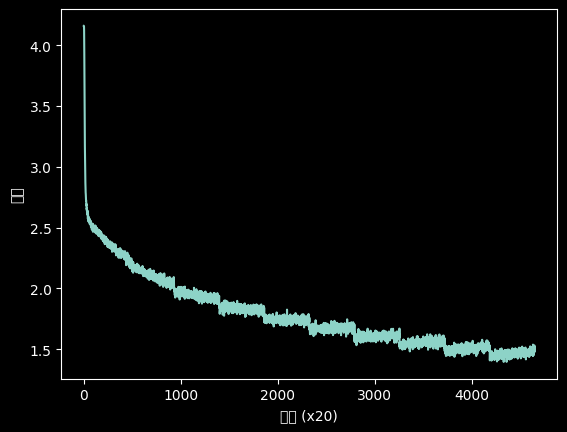

In [25]:
import pickle
from b2.common import config 
from b2.common.trainer import Trainer
from b2.common.optimizer import Adam
from b2.common.util import to_cpu, to_gpu
from datasets import ptb

config.GPU = True

window_size = 5
hidden_size = 100
batch_size = 100
max_epoch = 10

corpus, word_to_id, id_to_word = ptb.load_data('train')
vocab_size = len(word_to_id)

contexts, target = create_contexts_target(corpus, window_size)
if config.GPU:
    contexts, target = to_gpu(contexts), to_gpu(target)

model = CBOW(vocab_size, hidden_size, window_size, corpus)
optimizer = Adam()
trainer = Trainer(model, optimizer)

trainer.fit(contexts, target, max_epoch, batch_size)
trainer.plot()

word_vecs = model.word_vecs
if config.GPU:
    word_vecs = to_cpu(word_vecs)
params = {}
params['word_vecs'] = word_vecs.astype(np.float16)
params['word_to_id'] = word_to_id
params['id_to_word'] = id_to_word
pkl_file = 'cbow_params.pkl' 
with open(pkl_file, 'wb') as f:
    pickle.dump(params, f, -1)
